# COLAB 3: The Cloud-to-Edge Brain-Machine Interface

## Course architecture

Input design ➡️ On-device input processor ➡️ On-device output processor ➡️ Resource usage logger

**Platform Context:** MicroPython Runtime Architecture Layer (Simulated/Physical Target Host)  
**Motivating Domain:** Real-Time Embedded Neuroprosthetics & Wearable Edge Medical Devices  
**Target Open Dataset:** Live 100 Hz Streaming Packets

## Instructions for the student
You have successfully automated your pipeline and scaled it across multi-core cloud environments. Now comes the final deployment stage: moving your scientific insight directly onto a mobile edge device ([the BBC micro:bit V2 microcontroller](https://microbit.org)).

Microcontrollers are resource-constrained environments. A micro:bit V2 features only **128 KB of volatile RAM** and does not possess heavy scientific computing frameworks like `numpy` or `scipy`. Processing high-dimensional data arrays directly on this chip will cause immediate system memory exhaustion.

Your objective is to use the embedded **"AI Edge Challenges"** to prompt your AI assistant to build
1. a micro:bit-compatible input stream,
2. an on-device input processing program,
3. a resource usage logger.

While we encourage you to play around with the official [micro:bit simulator](https://makecode.microbit.org/#editor), for simplicity, we will simulate micro:bit's environment using the Python class below. You will implement its functionality step-by-step using AI prompting.

In [1]:
import numpy as np
import time
from datetime import datetime
from IPython.display import clear_output


class MicroBit:

    def __init__(self):
        super().__init__()

        self.MAX_RAM = 128 * 1024      # (bytes)
        self.MAX_STORAGE = 512 * 1024  # (bytes)

        self.buffer = []
        self.storage = []

    def ram_used(self):
        return np.array(self.buffer).nbytes

    def _is_ram_available(self):
        if self.ram_used() <= self.MAX_RAM:
            return True
        return False

    # --- Task 4: internal flash storage -------------------------------
    def storage_used(self):
        return np.array(self.storage).nbytes

    def _is_storage_available(self):
        return self.storage_used() <= self.MAX_STORAGE

    def output_to_screen(self, positions):
        clear_output(wait=True)
        grid = np.full((5, 5), '.', dtype=str)

        for r, c in positions:
            grid[r, c] = '*'

        for row in grid:
            print(' '.join(row))

    # --- Module 2 -----------------------------------------------------
    def read_from_temperature_sensor(self, input_stream, verbose=False,
                                     flush_to_storage=False):
        """Read a 1d array of sensor values into RAM, one sample at a time.

        verbose          -- Task 2: print live RAM usage while reading.
        flush_to_storage -- Task 4: when RAM fills up, move the buffer to
                            internal storage and keep reading instead of
                            failing.

        Returns 0 on success, 1 if the device ran out of RAM.
        """
        for value in input_stream:

            if not self._is_ram_available():
                if flush_to_storage and self.flush_buffer_to_storage() == 0:
                    pass  # RAM freed, carry on reading
                else:
                    print("[ERROR]: Out of RAM!")
                    return 1

            self.buffer.append(value)

            if verbose:
                clear_output(wait=True)
                print(f"[READING] Used RAM: {self.ram_used()} / "
                      f"{self.MAX_RAM} bytes "
                      f"({100 * self.ram_used() / self.MAX_RAM:.1f}%)")

        print(f"[SUCCESS] Used RAM: {self.ram_used()} bytes.")
        return 0

    # --- Module 3 -----------------------------------------------------
    def process_temperature_data(self, delay=0.02, show_digit=False):
        """Display each buffered reading on the 5x5 LED matrix.

        show_digit=False -- threshold mode: centre pixel if value > 25,
                            top-left pixel otherwise.
        show_digit=True  -- Task 3: render the first digit of the reading.
        """
        for value in self.buffer:

            if show_digit:
                first_digit = int(str(abs(int(value)))[0])
                self.output_to_screen(digit_to_positions(first_digit))
            elif value > 25:
                self.output_to_screen([(2, 2)])
            else:
                self.output_to_screen([(0, 0)])

            time.sleep(delay)

    # --- Module 4 -----------------------------------------------------
    def to_file(self, file):
        """Append a timestamped RAM-usage record; create the file if absent."""
        with open(file, "a") as f:
            f.write(f"{datetime.now().time()}\t{self.ram_used()}\n")

    # --- Task 4 -------------------------------------------------------
    def flush_buffer_to_storage(self):
        """Move everything currently in RAM into internal flash storage."""
        if not self._is_storage_available():
            print("[ERROR]: Out of storage!")
            return 1

        self.storage.extend(self.buffer)
        self.buffer = []
        return 0

## Module 1: Input design

### Mechanics

We will model input from the temperature sensor embedded into each micro:bit. On a real device, data arrives timestamp-by-timestamp as tiny voltage pulses sent over serial connections. Here we instantiate such a continuous signal loop, assuming it was received and is being stored in a buffer.

### Student AI prompt challenge

Copy and paste this text block into your AI assistant:

> Write a python function generate_temperature_signal() that takes the input sampling rate in Hz, the length of the signal in ms, and a random seed (default = 123) and generates a 1d numpy array with temperature readings in celcius. Each temperature value should be randomly sampled from a 20-to-30-degrees interval. Each temperature reading is a sum of the actual temperature value and device-specific noise (normal with small SD). Use np.random.RandomState as RNG.

In [2]:
def generate_temperature_signal(sampling_rate_hz, length_ms, random_seed=123):
    """Simulate a stream of temperature readings from an on-board sensor.

    Parameters
    ----------
    sampling_rate_hz : float   Samples acquired per second.
    length_ms        : float   Duration of the recording in milliseconds.
    random_seed      : int     Seed for reproducibility (default 123).

    Returns
    -------
    np.ndarray, shape (n_samples,) -- temperature in degrees Celsius,
    where each reading = true temperature + device-specific noise.
    """
    rng = np.random.RandomState(random_seed)

    n_samples = int(round(sampling_rate_hz * length_ms / 1000.0))
    if n_samples <= 0:
        return np.empty(0, dtype=float)

    true_temperature = rng.uniform(20.0, 30.0, size=n_samples)
    sensor_noise = rng.normal(loc=0.0, scale=0.1, size=n_samples)

    return true_temperature + sensor_noise


# 5x5 bitmaps for the micro:bit LED matrix, one per decimal digit.
DIGIT_PATTERNS = {
    0: ["*****", "*...*", "*...*", "*...*", "*****"],
    1: ["..*..", ".**..", "..*..", "..*..", ".***."],
    2: ["*****", "....*", "*****", "*....", "*****"],
    3: ["*****", "....*", "*****", "....*", "*****"],
    4: ["*...*", "*...*", "*****", "....*", "....*"],
    5: ["*****", "*....", "*****", "....*", "*****"],
    6: ["*****", "*....", "*****", "*...*", "*****"],
    7: ["*****", "....*", "...*.", "..*..", "..*.."],
    8: ["*****", "*...*", "*****", "*...*", "*****"],
    9: ["*****", "*...*", "*****", "....*", "*****"],
}


def digit_to_positions(digit):
    """Convert a 0-9 digit into the list of lit (row, col) LED coordinates."""
    pattern = DIGIT_PATTERNS[int(digit)]
    return [(r, c) for r, row in enumerate(pattern)
            for c, pixel in enumerate(row) if pixel == "*"]

Now we can generate a 5-second signal sampled at 100 Hz using 123 as a random seed and visualize the signal.

In [3]:
signal = generate_temperature_signal(sampling_rate_hz = 100, length_ms = 5000, random_seed = 123)

Text(0, 0.5, 'Temperature (deg C)')

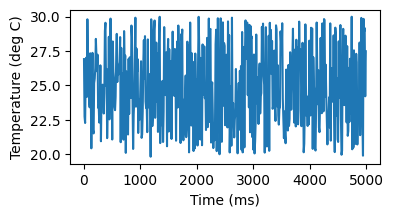

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize = (4, 2))

time_ms = np.arange(signal.size) * (1000 / 100)   # sample index -> milliseconds
ax.plot(time_ms, signal)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Temperature (deg C)")

## Module 2: On-device input processor

### Student AI prompt challenge

Copy and paste the `MicroBit` class below and this text block into your AI assistant:
> Write the function read_from_temperature_sensor assuming input_stream is a 1d numpy array. The function should read the array element-by-element, check if RAM is available, and if so, save the value into the buffer. It should print "[ERROR]: Out of RAM!" if no more RAM is available and return 1. If it managed to successfully read the whole stream, it should print f"[SUCCESS] Used RAM: {self.ram_used()} bytes." and return 0.

Modify the class above and run the cell below.

In [5]:
microbit = MicroBit()
microbit.read_from_temperature_sensor(signal)

[SUCCESS] Used RAM: 4000 bytes.


0

## Module 3: On-device output processor

### Student AI prompt challenge
Copy and paste the `MicroBit` class and this text block into your AI assistant:
> Now write the function process_temperature_data. It should read from the buffer value-by-value and if the value > 25, output to screen at position (2, 2), else output to screen at position (0, 0).

Modify the class above and run the cell below.

In [6]:
microbit.process_temperature_data(delay = 0.02)

. . . . .
. . . . .
. . * . .
. . . . .
. . . . .


## Module 4: Resource usage logger

### Student AI prompt challenge
Copy and paste the `MicroBit` class and this text block into your AI assistant:
> Now write the function to_file which takes the file name and appends the current time (datetime.now().time()) and the current RAM used. If the file does not exist, the function should automatically create it.

Modify the class above and run the cell below.

In [7]:
microbit.to_file("out.txt")

## Embedded playground

**Task 1.** Generate input that will make micro:bit run out of RAM.

**Task 2.** Modify the `read_from_temperature_sensor()` function to output used RAM while continuously reading input.

**Task 3.** Modify the `process_temperature_data()` function to display the first digit of the temperature.

**Task 4.** Prompt AI to make it possible to store sensor data in the micro:bit's internal storage.

### Task 1 — Make the micro:bit run out of RAM

`ram_used()` measures the buffer as a `float64` array, so every reading costs 8 bytes. The 128 KB ceiling is therefore hit at `128 * 1024 / 8 = 16384` samples. Sampling at 5 kHz for 5 seconds gives 25 000 readings — comfortably over the limit.

In [8]:
overflow_signal = generate_temperature_signal(sampling_rate_hz = 5000, length_ms = 5000, random_seed = 123)
print(f"Samples: {overflow_signal.size}, needed RAM: {overflow_signal.nbytes} bytes, "
      f"available: {MicroBit().MAX_RAM} bytes")

overflowed_microbit = MicroBit()
exit_code = overflowed_microbit.read_from_temperature_sensor(overflow_signal)
print(f"Exit code: {exit_code}, samples that fit: {len(overflowed_microbit.buffer)}")

Samples: 25000, needed RAM: 200000 bytes, available: 131072 bytes
[ERROR]: Out of RAM!
Exit code: 1, samples that fit: 16385


### Task 2 — Report RAM usage while reading

Pass `verbose = True` to `read_from_temperature_sensor()`. It clears the cell output on every sample and reprints the live figure, which is the closest analogue to watching a serial monitor scroll on a real device.

In [9]:
verbose_microbit = MicroBit()
verbose_microbit.read_from_temperature_sensor(signal, verbose = True)

[READING] Used RAM: 4000 / 131072 bytes (3.1%)
[SUCCESS] Used RAM: 4000 bytes.


0

### Task 3 — Display the first digit of the temperature

`digit_to_positions()` turns a digit into the list of lit `(row, col)` LEDs from the 5x5 bitmaps in `DIGIT_PATTERNS`. Readings sit between 20 and 30 degrees, so you should mostly see a `2`, with the occasional `3`.

In [10]:
digit_microbit = MicroBit()
digit_microbit.read_from_temperature_sensor(signal[:50])
digit_microbit.process_temperature_data(delay = 0.1, show_digit = True)

* * * * *
. . . . *
* * * * *
* . . . .
* * * * *


### Task 4 — Persist readings in internal storage

The class now tracks a 512 KB flash budget alongside RAM. `flush_buffer_to_storage()` empties the buffer into `self.storage`, and `read_from_temperature_sensor(..., flush_to_storage = True)` calls it automatically whenever RAM fills up — so a stream four times larger than RAM streams through without an error. The device still fails, correctly, once the 512 KB flash budget is also exhausted.

In [11]:
long_signal = generate_temperature_signal(sampling_rate_hz = 10000, length_ms = 5000, random_seed = 123)
print(f"Samples: {long_signal.size} ({long_signal.nbytes} bytes) vs {MicroBit().MAX_RAM} bytes of RAM")

storing_microbit = MicroBit()
exit_code = storing_microbit.read_from_temperature_sensor(long_signal, flush_to_storage = True)
print(f"Exit code: {exit_code}")
print(f"RAM: {storing_microbit.ram_used()} bytes | "
      f"Storage: {storing_microbit.storage_used()} / {storing_microbit.MAX_STORAGE} bytes")

Samples: 50000 (400000 bytes) vs 131072 bytes of RAM
[SUCCESS] Used RAM: 6760 bytes.
Exit code: 0
RAM: 6760 bytes | Storage: 393240 / 524288 bytes


In [12]:
microbit = MicroBit()
signal = generate_temperature_signal(sampling_rate_hz = 10, length_ms = 1000, random_seed = 123)

microbit.read_from_temperature_sensor(signal)
microbit.process_temperature_data()

* . . . .
. . . . .
. . . . .
. . . . .
. . . . .
